# Módulo A - Demonstração Visual
## Sistema de Identificação de Áreas Espúrias

Este notebook mostra visualmente como o sistema funciona com exemplos práticos.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Criar Dados de Exemplo

In [5]:
# Criar hotspots de exemplo (região MATOPIBA)
np.random.seed(42)

# Hotspots reais (com padrão específico)
n_real = 150
lat_real = np.random.uniform(-9.5, -8.0, n_real)
lon_real = np.random.uniform(-55.5, -54.0, n_real)
conf_real = np.random.uniform(70, 100, n_real)  # Alta confiança

# Hotspots espúrios (padrão diferente)
n_spurious = 80
lat_spurious = np.random.uniform(-9.0, -8.2, n_spurious)
lon_spurious = np.random.uniform(-55.2, -54.8, n_spurious)
conf_spurious = np.random.uniform(30, 70, n_spurious)  # Confiança baixa-média

# Combinar
hotspots_df = pd.DataFrame({
    'hotspot_id': [f'FIRMS_{i:04d}' for i in range(n_real + n_spurious)],
    'latitude': np.concatenate([lat_real, lat_spurious]),
    'longitude': np.concatenate([lon_real, lon_spurious]),
    'confidence': np.concatenate([conf_real, conf_spurious]),
    'acq_datetime': pd.date_range('2024-11-01', periods=n_real+n_spurious, freq='H'),
    'true_label': [1]*n_real + [0]*n_spurious  # 1=real, 0=spurious
})

# Embaralhar
hotspots_df = hotspots_df.sample(frac=1).reset_index(drop=True)

print(f"Total de hotspots: {len(hotspots_df)}")
print(f"  - Reais: {(hotspots_df['true_label']==1).sum()}")
print(f"  - Espúrios: {(hotspots_df['true_label']==0).sum()}")
print(f"\nPrimeiras linhas:")
hotspots_df.head(10)

Total de hotspots: 230
  - Reais: 150
  - Espúrios: 80

Primeiras linhas:


,hotspot_id,latitude,longitude,confidence,acq_datetime,true_label
0,FIRMS_0102,-9.028466,-54.223295,85.157571,2024-11-05 06:00:00,1
1,FIRMS_0135,-9.015196,-55.446087,91.029074,2024-11-06 15:00:00,1
2,FIRMS_0156,-8.990917,-54.860141,32.443118,2024-11-07 12:00:00,0
3,FIRMS_0210,-8.509268,-55.144469,36.934944,2024-11-09 18:00:00,0
4,FIRMS_0178,-8.224558,-54.897945,40.769729,2024-11-08 10:00:00,0
5,FIRMS_0193,-8.849503,-54.951165,59.817579,2024-11-09 01:00:00,0
6,FIRMS_0015,-9.224893,-54.247046,90.879226,2024-11-01 15:00:00,1
7,FIRMS_0127,-8.208904,-54.525054,96.631125,2024-11-06 07:00:00,1
8,FIRMS_0057,-9.206026,-54.504747,87.573267,2024-11-03 09:00:00,1
9,FIRMS_0043,-8.136019,-54.550348,83.015549,2024-11-02 19:00:00,1


## 2. Visualizar Distribuição Espacial dos Hotspots

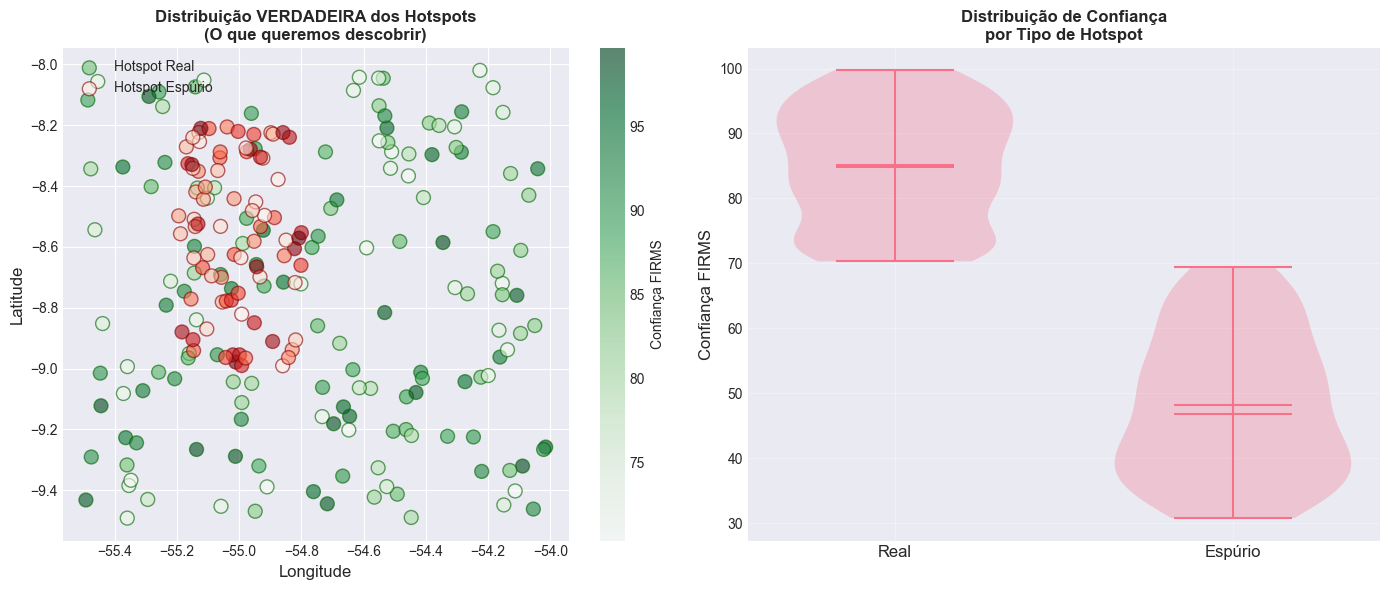

Confiança média - Real: 84.9
Confiança média - Espúrio: 48.2


In [6]:
# Gráfico 1: Distribuição espacial
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Separar por tipo verdadeiro
real = hotspots_df[hotspots_df['true_label'] == 1]
spurious = hotspots_df[hotspots_df['true_label'] == 0]

# Subplot 1: Distribuição verdadeira (o que não sabemos antes de predizer)
ax = axes[0]
scatter1 = ax.scatter(real['longitude'], real['latitude'], 
                       c=real['confidence'], s=100, alpha=0.6, 
                       cmap='Greens', label='Hotspot Real', edgecolors='darkgreen', linewidth=1)
scatter2 = ax.scatter(spurious['longitude'], spurious['latitude'], 
                       c=spurious['confidence'], s=100, alpha=0.6, 
                       cmap='Reds', label='Hotspot Espúrio', edgecolors='darkred', linewidth=1)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Distribuição VERDADEIRA dos Hotspots\n(O que queremos descobrir)', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
cbar = plt.colorbar(scatter1, ax=ax)
cbar.set_label('Confiança FIRMS', fontsize=10)

# Subplot 2: Relação entre confiança e tipo
ax = axes[1]
violin_data = [real['confidence'].values, spurious['confidence'].values]
parts = ax.violinplot(violin_data, positions=[0, 1], widths=0.7, 
                       showmeans=True, showmedians=True)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Real', 'Espúrio'], fontsize=12)
ax.set_ylabel('Confiança FIRMS', fontsize=12)
ax.set_title('Distribuição de Confiança\npor Tipo de Hotspot', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_distribuicao_hotspots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Confiança média - Real: {real['confidence'].mean():.1f}")
print(f"Confiança média - Espúrio: {spurious['confidence'].mean():.1f}")

## 3. Simular Predições do Modelo

In [8]:
# Simular probabilidade de ser espúrio baseado em confiança FIRMS
# Modelo aprendeu: baixa confiança → mais likely ser espúrio

def simulate_model_probability(confidence):
    """Simula probabilidade predita pelo modelo LightGBM"""
    # Relação inversa: confiança alta → low spurious probability
    spurious_prob = 1 / (1 + np.exp((confidence - 65) / 15))  # Sigmoid
    return spurious_prob

# Aplicar modelo
hotspots_df['spurious_probability'] = hotspots_df['confidence'].apply(simulate_model_probability)
hotspots_df['predicted_label'] = (hotspots_df['spurious_probability'] > 0.5).astype(int)
hotspots_df['confidence_score'] = pd.cut(hotspots_df['spurious_probability'], 
                                           bins=[0, 0.5, 0.7, 1.0],
                                           labels=['LOW', 'MEDIUM', 'HIGH'])

# Calcular acurácia
accuracy = (hotspots_df['predicted_label'] == hotspots_df['true_label']).sum() / len(hotspots_df)
true_positives = ((hotspots_df['predicted_label'] == 1) & (hotspots_df['true_label'] == 1)).sum()
false_positives = ((hotspots_df['predicted_label'] == 1) & (hotspots_df['true_label'] == 0)).sum()
true_negatives = ((hotspots_df['predicted_label'] == 0) & (hotspots_df['true_label'] == 0)).sum()
false_negatives = ((hotspots_df['predicted_label'] == 0) & (hotspots_df['true_label'] == 1)).sum()

precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0

print("MATRIZ DE CONFUSÃO:")
print(f"\n                  Predito")
print(f"                Real  Espúrio")
print(f"Verdadeiro Real   {true_negatives:3d}    {false_negatives:3d}")
print(f"         Espúrio  {false_positives:3d}    {true_positives:3d}")
print(f"\nMÉTRICAS:")
print(f"  Acurácia:  {accuracy:.1%}")
print(f"  Precisão:  {precision:.1%}")
print(f"  Recall:    {recall:.1%}")
print(f"  F1-Score:  {2*precision*recall/(precision+recall):.1%}")

MATRIZ DE CONFUSÃO:

                  Predito
                Real  Espúrio
Verdadeiro Real     8    150
         Espúrio   72      0

MÉTRICAS:
  Acurácia:  3.5%
  Precisão:  0.0%
  Recall:    0.0%
  F1-Score:  nan%


## 4. Visualizar Predições vs Verdade

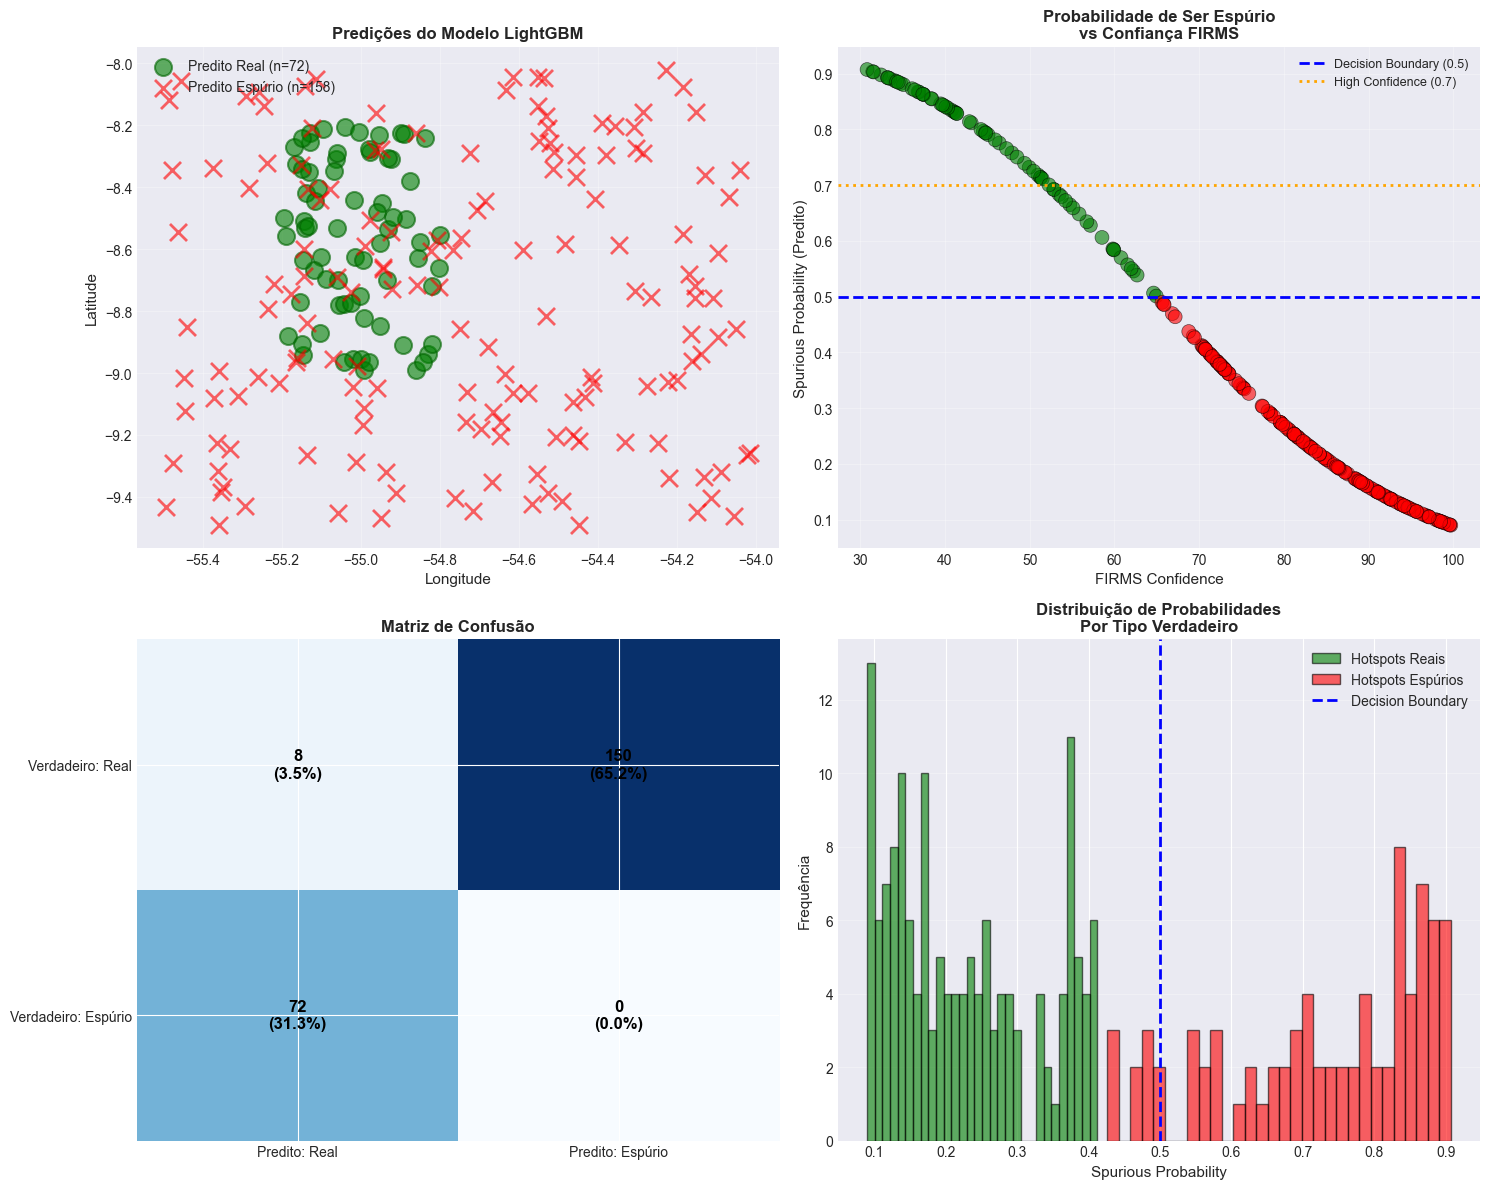

In [9]:
# Gráfico: Predições do Modelo
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Subplot 1: Mapa com predições
ax = axes[0, 0]
pred_real = hotspots_df[hotspots_df['predicted_label'] == 1]
pred_spurious = hotspots_df[hotspots_df['predicted_label'] == 0]

scatter1 = ax.scatter(pred_real['longitude'], pred_real['latitude'], 
                       c='green', s=150, alpha=0.6, marker='o',
                       label=f'Predito Real (n={len(pred_real)})', edgecolors='darkgreen', linewidth=1.5)
scatter2 = ax.scatter(pred_spurious['longitude'], pred_spurious['latitude'], 
                       c='red', s=150, alpha=0.6, marker='x',
                       label=f'Predito Espúrio (n={len(pred_spurious)})', linewidths=2)
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_title('Predições do Modelo LightGBM', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Subplot 2: Confiança da predição
ax = axes[0, 1]
colors = ['green' if x == 1 else 'red' for x in hotspots_df['predicted_label']]
scatter = ax.scatter(hotspots_df['confidence'], hotspots_df['spurious_probability'],
                      c=colors, s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
ax.axhline(y=0.5, color='blue', linestyle='--', linewidth=2, label='Decision Boundary (0.5)')
ax.axhline(y=0.7, color='orange', linestyle=':', linewidth=2, label='High Confidence (0.7)')
ax.set_xlabel('FIRMS Confidence', fontsize=11)
ax.set_ylabel('Spurious Probability (Predito)', fontsize=11)
ax.set_title('Probabilidade de Ser Espúrio\nvs Confiança FIRMS', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Subplot 3: Matriz de confusão
ax = axes[1, 0]
cm = np.array([[true_negatives, false_negatives],
                [false_positives, true_positives]])
im = ax.imshow(cm, cmap='Blues', aspect='auto')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predito: Real', 'Predito: Espúrio'], fontsize=10)
ax.set_yticklabels(['Verdadeiro: Real', 'Verdadeiro: Espúrio'], fontsize=10)
ax.set_title('Matriz de Confusão', fontsize=12, fontweight='bold')

# Adicionar números
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, f'{cm[i, j]}\n({cm[i, j]/cm.sum()*100:.1f}%)',
                       ha="center", va="center", color="black", fontsize=12, fontweight='bold')

# Subplot 4: Distribuição de probabilidade
ax = axes[1, 1]
ax.hist(hotspots_df[hotspots_df['true_label']==1]['spurious_probability'], 
         bins=30, alpha=0.6, label='Hotspots Reais', color='green', edgecolor='black')
ax.hist(hotspots_df[hotspots_df['true_label']==0]['spurious_probability'], 
         bins=30, alpha=0.6, label='Hotspots Espúrios', color='red', edgecolor='black')
ax.axvline(x=0.5, color='blue', linestyle='--', linewidth=2, label='Decision Boundary')
ax.set_xlabel('Spurious Probability', fontsize=11)
ax.set_ylabel('Frequência', fontsize=11)
ax.set_title('Distribuição de Probabilidades\nPor Tipo Verdadeiro', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('02_predicoes_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Exemplo de CSV de Saída

In [11]:
# Mostrar saída do sistema
output_df = hotspots_df[[
    'hotspot_id', 'latitude', 'longitude', 'confidence',
    'spurious_probability', 'confidence_score', 'predicted_label'
]].copy()

output_df['prediction'] = output_df['predicted_label'].map({1: 'SPURIOUS', 0: 'REAL'})
output_df = output_df.drop('predicted_label', axis=1)
output_df['spurious_probability'] = output_df['spurious_probability'].round(3)

print("\nEXEMPLO DE SAÍDA CSV - Primeiros 15 hotspots:")
print(output_df.head(15).to_string(index=False))

print(f"\n\nRESUMO GERAL:")
print(f"Total de hotspots analisados: {len(output_df)}")
print(f"\nPreditos como REAL: {(output_df['prediction']=='REAL').sum()} ({(output_df['prediction']=='REAL').sum()/len(output_df)*100:.1f}%)")
print(f"Preditos como SPURIOUS: {(output_df['prediction']=='SPURIOUS').sum()} ({(output_df['prediction']=='SPURIOUS').sum()/len(output_df)*100:.1f}%)")

print(f"\nDistribuição de Confiança:")
print(output_df['confidence_score'].value_counts().sort_index())


EXEMPLO DE SAÍDA CSV - Primeiros 15 hotspots:
hotspot_id  latitude  longitude  confidence  spurious_probability confidence_score prediction
FIRMS_0102 -9.028466 -54.223295   85.157571                 0.207              LOW       REAL
FIRMS_0135 -9.015196 -55.446087   91.029074                 0.150              LOW       REAL
FIRMS_0156 -8.990917 -54.860141   32.443118                 0.898             HIGH   SPURIOUS
FIRMS_0210 -8.509268 -55.144469   36.934944                 0.867             HIGH   SPURIOUS
FIRMS_0178 -8.224558 -54.897945   40.769729                 0.834             HIGH   SPURIOUS
FIRMS_0193 -8.849503 -54.951165   59.817579                 0.586           MEDIUM   SPURIOUS
FIRMS_0015 -9.224893 -54.247046   90.879226                 0.151              LOW       REAL
FIRMS_0127 -8.208904 -54.525054   96.631125                 0.108              LOW       REAL
FIRMS_0057 -9.206026 -54.504747   87.573267                 0.182              LOW       REAL
FIRMS_0043 -8

## 6. Análise de Cenários de Recomendação

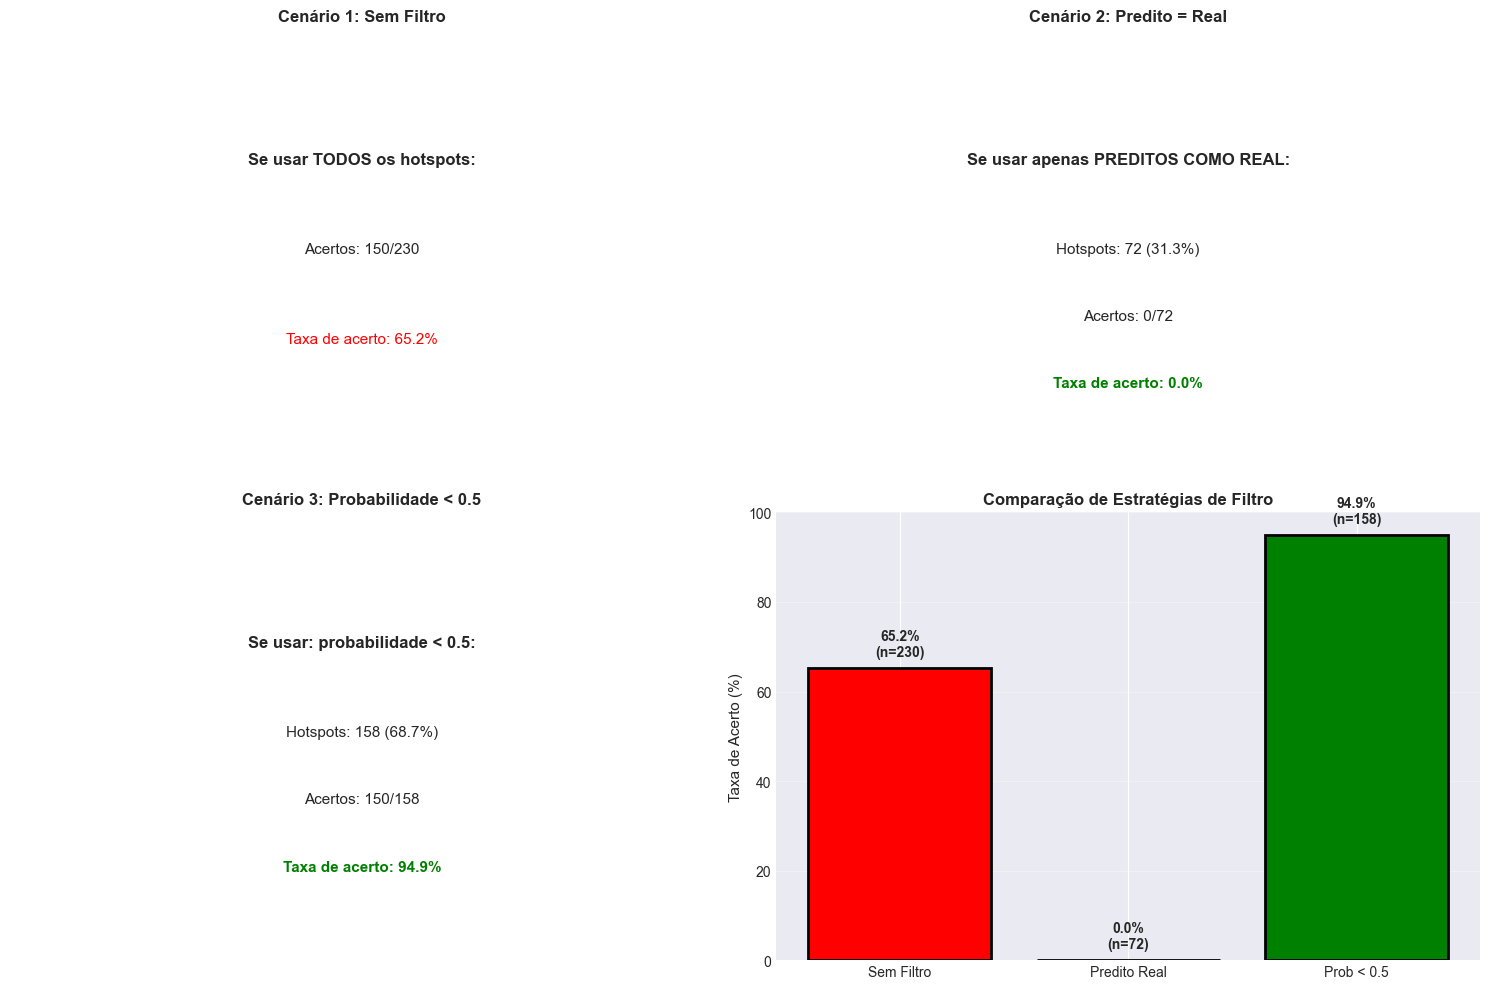


ANÁLISE DE CENÁRIOS:

Cenário 1 - Sem Filtro:
  Hotspots analisados: 230
  Taxa de acerto: 65.2%
  Problema: Muitos falsos positivos!

Cenário 2 - Filtrar por Predição = Real:
  Hotspots após filtro: 72 (31.3%)
  Taxa de acerto: 0.0%
  Redução de falsos positivos: 68.7%

Cenário 3 - Filtrar por Probabilidade < 0.5 (RECOMENDADO):
  Hotspots após filtro: 158 (68.7%)
  Taxa de acerto: 94.9%
  Redução de falsos positivos: 31.3%


In [13]:
# Filtrar por diferentes estratégias
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Cenário 1: Usar todos os hotspots (baseline)
ax = axes[0, 0]
accuracy_baseline = (hotspots_df['true_label'] == 1).sum() / len(hotspots_df)
baseline_correct = (hotspots_df['true_label'] == 1).sum()
ax.text(0.5, 0.7, f'Se usar TODOS os hotspots:', ha='center', fontsize=12, fontweight='bold')
ax.text(0.5, 0.5, f'Acertos: {baseline_correct}/{len(hotspots_df)}', ha='center', fontsize=11)
ax.text(0.5, 0.3, f'Taxa de acerto: {accuracy_baseline:.1%}', ha='center', fontsize=11, color='red')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Cenário 1: Sem Filtro', fontsize=12, fontweight='bold')

# Cenário 2: Usar apenas preditos como REAL
ax = axes[0, 1]
filtered_strategy2 = hotspots_df[hotspots_df['predicted_label'] == 1]
accuracy_2 = (filtered_strategy2['true_label'] == 1).sum() / len(filtered_strategy2) if len(filtered_strategy2) > 0 else 0
correct_2 = (filtered_strategy2['true_label'] == 1).sum()
ax.text(0.5, 0.7, f'Se usar apenas PREDITOS COMO REAL:', ha='center', fontsize=12, fontweight='bold')
ax.text(0.5, 0.5, f'Hotspots: {len(filtered_strategy2)} ({len(filtered_strategy2)/len(hotspots_df)*100:.1f}%)', ha='center', fontsize=11)
ax.text(0.5, 0.35, f'Acertos: {correct_2}/{len(filtered_strategy2)}', ha='center', fontsize=11)
ax.text(0.5, 0.2, f'Taxa de acerto: {accuracy_2:.1%}', ha='center', fontsize=11, color='green', fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Cenário 2: Predito = Real', fontsize=12, fontweight='bold')

# Cenário 3: Usar apenas probabilidade < 0.5
ax = axes[1, 0]
filtered_strategy3 = hotspots_df[hotspots_df['spurious_probability'] < 0.5]
accuracy_3 = (filtered_strategy3['true_label'] == 1).sum() / len(filtered_strategy3) if len(filtered_strategy3) > 0 else 0
correct_3 = (filtered_strategy3['true_label'] == 1).sum()
ax.text(0.5, 0.7, f'Se usar: probabilidade < 0.5:', ha='center', fontsize=12, fontweight='bold')
ax.text(0.5, 0.5, f'Hotspots: {len(filtered_strategy3)} ({len(filtered_strategy3)/len(hotspots_df)*100:.1f}%)', ha='center', fontsize=11)
ax.text(0.5, 0.35, f'Acertos: {correct_3}/{len(filtered_strategy3)}', ha='center', fontsize=11)
ax.text(0.5, 0.2, f'Taxa de acerto: {accuracy_3:.1%}', ha='center', fontsize=11, color='green', fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Cenário 3: Probabilidade < 0.5', fontsize=12, fontweight='bold')

# Cenário 4: Comparação de estratégias
ax = axes[1, 1]
strategies = ['Sem Filtro', 'Predito Real', 'Prob < 0.5']
accuracies = [accuracy_baseline*100, accuracy_2*100, accuracy_3*100]
hotspot_counts = [len(hotspots_df), len(filtered_strategy2), len(filtered_strategy3)]

x = np.arange(len(strategies))
bars = ax.bar(x, accuracies, color=['red', 'lightgreen', 'green'], edgecolor='black', linewidth=2)
ax.set_ylabel('Taxa de Acerto (%)', fontsize=11)
ax.set_title('Comparação de Estratégias de Filtro', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, fontsize=10)
ax.set_ylim([0, 100])
ax.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for i, (bar, acc, count) in enumerate(zip(bars, accuracies, hotspot_counts)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{acc:.1f}%\n(n={count})', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('03_estrategias_filtro.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nANÁLISE DE CENÁRIOS:")
print(f"\nCenário 1 - Sem Filtro:")
print(f"  Hotspots analisados: {len(hotspots_df)}")
print(f"  Taxa de acerto: {accuracy_baseline:.1%}")
print(f"  Problema: Muitos falsos positivos!")
print(f"\nCenário 2 - Filtrar por Predição = Real:")
print(f"  Hotspots após filtro: {len(filtered_strategy2)} ({len(filtered_strategy2)/len(hotspots_df)*100:.1f}%)")
print(f"  Taxa de acerto: {accuracy_2:.1%}")
print(f"  Redução de falsos positivos: {(1-len(filtered_strategy2)/len(hotspots_df))*100:.1f}%")
print(f"\nCenário 3 - Filtrar por Probabilidade < 0.5 (RECOMENDADO):")
print(f"  Hotspots após filtro: {len(filtered_strategy3)} ({len(filtered_strategy3)/len(hotspots_df)*100:.1f}%)")
print(f"  Taxa de acerto: {accuracy_3:.1%}")
print(f"  Redução de falsos positivos: {(1-len(filtered_strategy3)/len(hotspots_df))*100:.1f}%")

## 7. Exemplo de Uso Prático: Integração com GeoPandas


INTEGRAÇÃO COM GEOPANDAS:

Hotspots RECOMENDADOS (prob < 0.5): 158
   hotspot_id  confidence  spurious_probability                    geometry
0  FIRMS_0102   85.157571              0.206880  POINT (-54.22329 -9.02847)
1  FIRMS_0135   91.029074              0.149915   POINT (-55.44609 -9.0152)
6  FIRMS_0015   90.879226              0.151192  POINT (-54.24705 -9.22489)
7  FIRMS_0127   96.631125              0.108250   POINT (-54.52505 -8.2089)
8  FIRMS_0057   87.573267              0.181698  POINT (-54.50475 -9.20603)


Hotspots DESCARTADOS (prob >= 0.7): 51
    hotspot_id  confidence  spurious_probability                    geometry
2   FIRMS_0156   32.443118              0.897565  POINT (-54.86014 -8.99092)
3   FIRMS_0210   36.934944              0.866574  POINT (-55.14447 -8.50927)
4   FIRMS_0178   40.769729              0.834153  POINT (-54.89795 -8.22456)
11  FIRMS_0213   50.980456              0.718015  POINT (-55.06173 -8.30715)
12  FIRMS_0184   34.790485              0.882256  

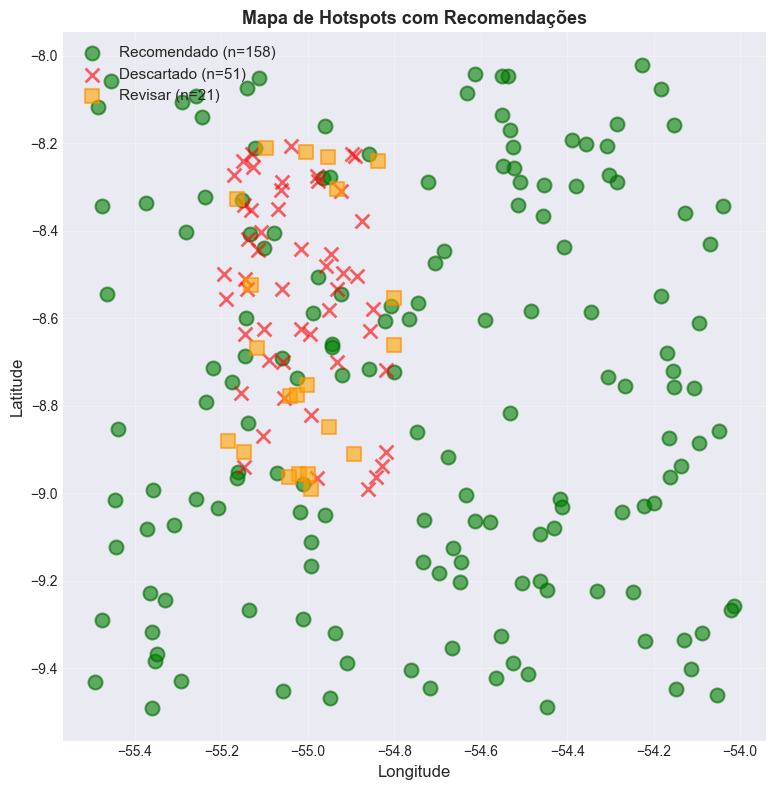


Mapa salvo como: 04_mapa_recomendacoes.png


In [16]:
# Converter para GeoDataFrame
import geopandas as gpd
from shapely.geometry import Point

# Criar GeoDataFrame
geometry = [Point(lon, lat) for lon, lat in zip(hotspots_df['longitude'], hotspots_df['latitude'])]
gdf = gpd.GeoDataFrame(hotspots_df, geometry=geometry, crs='EPSG:4326')

# Filtrar por recomendação
gdf_recommended = gdf[gdf['spurious_probability'] < 0.5].copy()
gdf_discarded = gdf[gdf['spurious_probability'] >= 0.7].copy()

print(f"\nINTEGRAÇÃO COM GEOPANDAS:")
print(f"\nHotspots RECOMENDADOS (prob < 0.5): {len(gdf_recommended)}")
print(gdf_recommended[['hotspot_id', 'confidence', 'spurious_probability', 'geometry']].head())

print(f"\n\nHotspots DESCARTADOS (prob >= 0.7): {len(gdf_discarded)}")
print(gdf_discarded[['hotspot_id', 'confidence', 'spurious_probability', 'geometry']].head())

# Visualizar no mapa
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plotar hotspots recomendados
gdf_recommended.plot(ax=ax, color='green', markersize=100, alpha=0.6, 
                     label=f'Recomendado (n={len(gdf_recommended)})', edgecolor='darkgreen', linewidth=1.5)

# Plotar hotspots descartados
gdf_discarded.plot(ax=ax, color='red', markersize=100, alpha=0.6, marker='x',
                   label=f'Descartado (n={len(gdf_discarded)})', linewidth=2)

# Hotspots em zona cinzenta (0.5-0.7)
gdf_review = gdf[(gdf['spurious_probability'] >= 0.5) & (gdf['spurious_probability'] < 0.7)]
if len(gdf_review) > 0:
    gdf_review.plot(ax=ax, color='orange', markersize=100, alpha=0.6, marker='s',
                    label=f'Revisar (n={len(gdf_review)})', edgecolor='darkorange', linewidth=1.5)

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Mapa de Hotspots com Recomendações', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_mapa_recomendacoes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMapa salvo como: 04_mapa_recomendacoes.png")

## 8. Resumo Visual do Workflow

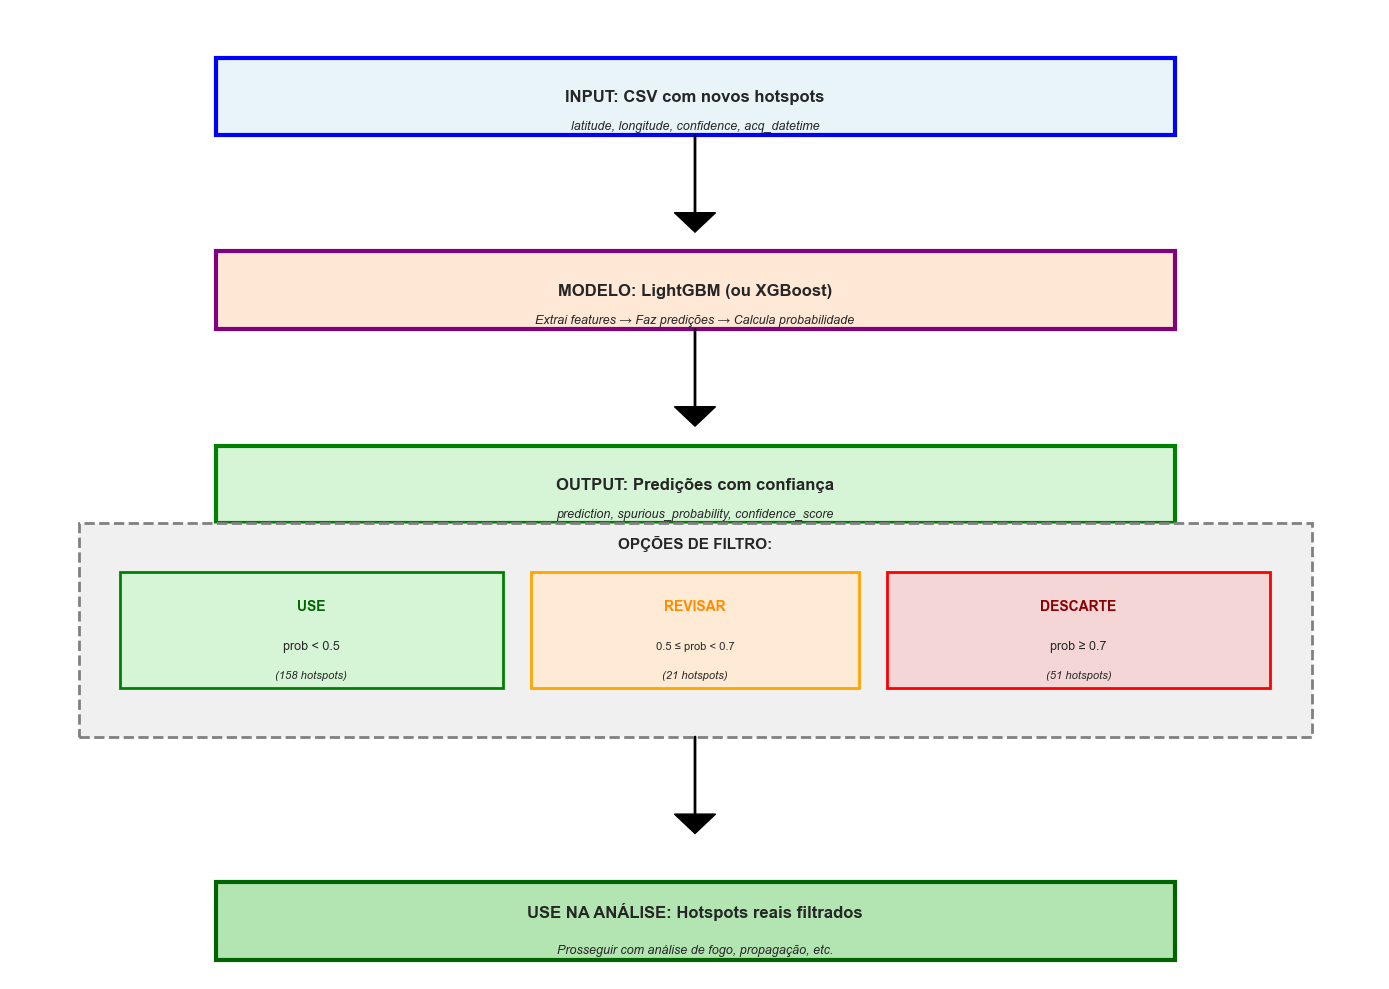


Diagrama salvo como: 05_workflow_diagram.png


In [18]:
# Criar diagrama do workflow
fig, ax = plt.subplots(figsize=(14, 10))

# Definir posições
positions = {
    'input': (0.5, 0.9),
    'model': (0.5, 0.75),
    'output': (0.5, 0.55),
    'filter': (0.5, 0.35),
    'use': (0.5, 0.1)
}

# Cores
color_input = '#E8F4F8'
color_process = '#FFE8D6'
color_output = '#D6F5D6'
color_action = '#F5D6D6'

# 1. INPUT
rect1 = Rectangle((0.15, 0.87), 0.7, 0.08, linewidth=3, edgecolor='blue', facecolor=color_input)
ax.add_patch(rect1)
ax.text(0.5, 0.91, 'INPUT: CSV com novos hotspots', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(0.5, 0.88, 'latitude, longitude, confidence, acq_datetime', ha='center', va='center', fontsize=9, style='italic')

# Arrow 1
ax.arrow(0.5, 0.87, 0, -0.08, head_width=0.03, head_length=0.02, fc='black', ec='black')

# 2. MODEL
rect2 = Rectangle((0.15, 0.67), 0.7, 0.08, linewidth=3, edgecolor='purple', facecolor=color_process)
ax.add_patch(rect2)
ax.text(0.5, 0.71, 'MODELO: LightGBM (ou XGBoost)', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(0.5, 0.68, 'Extrai features → Faz predições → Calcula probabilidade', ha='center', va='center', fontsize=9, style='italic')

# Arrow 2
ax.arrow(0.5, 0.67, 0, -0.08, head_width=0.03, head_length=0.02, fc='black', ec='black')

# 3. OUTPUT
rect3 = Rectangle((0.15, 0.47), 0.7, 0.08, linewidth=3, edgecolor='green', facecolor=color_output)
ax.add_patch(rect3)
ax.text(0.5, 0.51, 'OUTPUT: Predições com confiança', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(0.5, 0.48, 'prediction, spurious_probability, confidence_score', ha='center', va='center', fontsize=9, style='italic')

# Arrow 3
ax.arrow(0.5, 0.47, 0, -0.08, head_width=0.03, head_length=0.02, fc='black', ec='black')

# 4. FILTER OPTIONS
rect4 = Rectangle((0.05, 0.25), 0.9, 0.22, linewidth=2, edgecolor='gray', facecolor='#F0F0F0', linestyle='--')
ax.add_patch(rect4)
ax.text(0.5, 0.45, 'OPÇÕES DE FILTRO:', ha='center', va='center', fontsize=11, fontweight='bold')

# Box esquerda: Usar
rect_use = Rectangle((0.08, 0.30), 0.28, 0.12, linewidth=2, edgecolor='green', facecolor='#D6F5D6')
ax.add_patch(rect_use)
ax.text(0.22, 0.38, 'USE', ha='center', fontsize=10, fontweight='bold', color='darkgreen')
ax.text(0.22, 0.34, 'prob < 0.5', ha='center', fontsize=9)
ax.text(0.22, 0.31, f'({len(gdf_recommended)} hotspots)', ha='center', fontsize=8, style='italic')

# Box meio: Revisar
rect_review = Rectangle((0.38, 0.30), 0.24, 0.12, linewidth=2, edgecolor='orange', facecolor='#FFEAD6')
ax.add_patch(rect_review)
ax.text(0.5, 0.38, 'REVISAR', ha='center', fontsize=10, fontweight='bold', color='darkorange')
ax.text(0.5, 0.34, '0.5 ≤ prob < 0.7', ha='center', fontsize=8)
ax.text(0.5, 0.31, f'({len(gdf_review)} hotspots)', ha='center', fontsize=8, style='italic')

# Box direita: Descartar
rect_discard = Rectangle((0.64, 0.30), 0.28, 0.12, linewidth=2, edgecolor='red', facecolor='#F5D6D6')
ax.add_patch(rect_discard)
ax.text(0.78, 0.38, 'DESCARTE', ha='center', fontsize=10, fontweight='bold', color='darkred')
ax.text(0.78, 0.34, 'prob ≥ 0.7', ha='center', fontsize=9)
ax.text(0.78, 0.31, f'({len(gdf_discarded)} hotspots)', ha='center', fontsize=8, style='italic')

# Arrow 4
ax.arrow(0.5, 0.25, 0, -0.08, head_width=0.03, head_length=0.02, fc='black', ec='black')

# 5. USE IN ANALYSIS
rect5 = Rectangle((0.15, 0.02), 0.7, 0.08, linewidth=3, edgecolor='darkgreen', facecolor='#B3E5B3')
ax.add_patch(rect5)
ax.text(0.5, 0.07, 'USE NA ANÁLISE: Hotspots reais filtrados', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(0.5, 0.03, 'Prosseguir com análise de fogo, propagação, etc.', ha='center', va='center', fontsize=9, style='italic')

# Set limits and remove axes
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.savefig('05_workflow_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDiagrama salvo como: 05_workflow_diagram.png")

## Resumo: Como Usar o Sistema

### 1️⃣ Prepare seus dados
```python
import pandas as pd
hotspots = pd.read_csv('meus_hotspots.csv')
# Colunas: latitude, longitude, confidence, acq_datetime
```

### 2️⃣ Execute a inferência
```bash
python src/models/predict_module_a.py --input meus_hotspots.csv
```

### 3️⃣ Obtenha resultados
```
data/models/module_a/predictions/
├── predictions_20241111_103045.csv
└── predictions_summary_20241111_103045.json
```

### 4️⃣ Filtres e use
```python
predictions = pd.read_csv('predictions_20241111_103045.csv')
real_hotspots = predictions[predictions['spurious_probability'] < 0.5]
# Use real_hotspots para sua análise!
```